<a href="https://colab.research.google.com/github/sdromigny/SOLA_4th_year_projects/blob/main/Pyekfmm_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tutorial to run pyekfmm.
Try to change the velocity model to a 10x10x10 grid with a first layer at 5.5 km/s and the rest of the layers at 5.76 km/s (keep the source and receiver locations for now as they are)

#Installing the library
Please don't hesitate to have a look at the source code: https://github.com/aaspip/pyekfmm


In [10]:
! pip install pyekfmm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyseistr: filename=pyseistr-0.0.4.4.2-cp312-cp312-linux_x86_64.whl size=525962 sha256=e994134d54741c4eed5102d57876431bbfd118d65891703eddc5da5e09ce069c
  Stored in directory: /root/.cache/pip/wheels/3d/a7/1e/f516632152c9bfba735a55b4963f65de4917f7ba5bc9da9600
Successfully built pyseistr


#Importing the libraries

In [11]:

import pyekfmm as fmm
import numpy as np
import matplotlib.pyplot as plt


#Setting up the grid

In [5]:

### 3D grid (currently only allow dx=dy=dz)
v1=3;
v2=4;
v3=5;
nz=301;
nx=51;
ny=51;
dx=0.01;
dz=0.01;
dy=0.01;
sx=0;
sy=0.25;
sz=0;

z=np.arange(nz)*dz;
y=np.arange(ny)*dy;
x=np.arange(nx)*dx;

#Populate the grid with the velocity model values

In [6]:

## create or load velocity model [z,x,y]
vel3d=v1*np.ones([nz,nx,ny],dtype='float32');
vel3d[100:200, :, :]=v2
vel3d[200:301, :, :]=v3

## velocity dimension swap [z,x,y] -> [x,y,z]
vxyz=np.swapaxes(np.swapaxes(vel3d,0,1),1,2);
#or
vxyz=np.transpose(vel3d,[1,2,0]);

#Fast Marching Method calculation: what the traveltimes through the medium will be

In [7]:

## FMM calculation
t=fmm.eikonal(vxyz.flatten(order='F'),xyz=np.array([sx,sy,sz]),ax=[0,dx,nx],ay=[0,dy,ny],az=[0,dz,nz],order=2);
time=t.reshape(nx,ny,nz,order='F');#first axis (vertical) is x, second is y, third is z
tzxy=np.swapaxes(np.swapaxes(time,1,2),0,1);
#or
tzxy=np.transpose(time,[2,0,1]);

#Plot the expected traveltimes from FMM and the velocity model

/usr/local/lib/python3.12/dist-packages/pyekfmm/plot.py:121: UserWarning: The following kwargs were not used by contour: 'barlabel'
  _ = ax.contourf(
/usr/local/lib/python3.12/dist-packages/pyekfmm/plot.py:126: UserWarning: The following kwargs were not used by contour: 'barlabel'
  _ = ax.contourf(
/usr/local/lib/python3.12/dist-packages/pyekfmm/plot.py:131: UserWarning: The following kwargs were not used by contour: 'barlabel'
  C = ax.contourf(


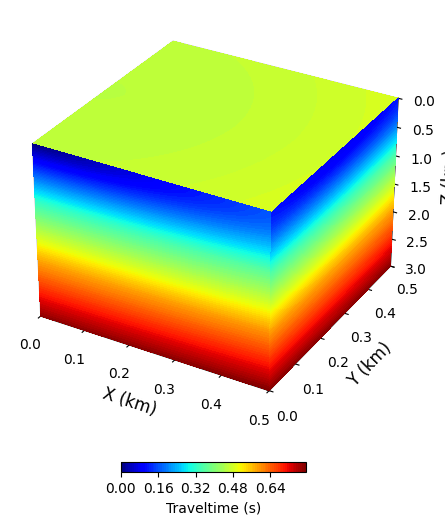

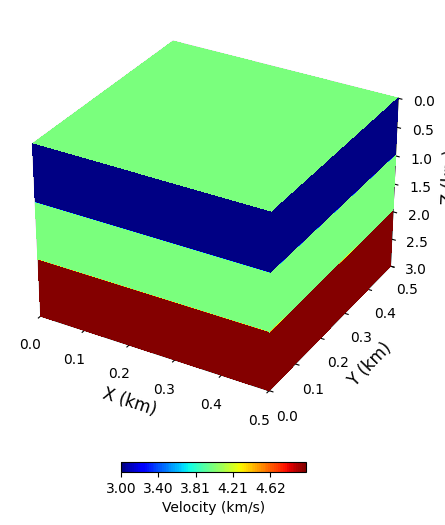

In [8]:

## plot 3D velocity model
from pyekfmm import plot3d
# plot3d(tzxy,cmap=plt.cm.jet,barlabel='Traveltime (s)',figname='vel3d.png',format='png',dpi=300)
plot3d(tzxy,dz=dz,dx=dx,dy=dy,cmap=plt.cm.jet,barlabel='Traveltime (s)',showf=False,close=False);
plt.gca().set_xlabel("X (km)",fontsize='large', fontweight='normal')
plt.gca().set_ylabel("Y (km)",fontsize='large', fontweight='normal')
plt.gca().set_zlabel("Z (km)",fontsize='large', fontweight='normal')
plt.show()

# plot3d(vel3d,cmap=plt.cm.jet,barlabel='Velocity (km/s)',figname='vel3d.png',format='png',dpi=300)#,figname='time3d.png',format='png',dpi=300)
plot3d(vel3d,x=x,y=y,z=z,cmap=plt.cm.jet,barlabel='Velocity (km/s)',showf=False,close=False);
plt.gca().set_xlabel("X (km)",fontsize='large', fontweight='normal')
plt.gca().set_ylabel("Y (km)",fontsize='large', fontweight='normal')
plt.gca().set_zlabel("Z (km)",fontsize='large', fontweight='normal')
plt.show()

#How the rays travel through the medium

Second break
Before trim (3, 676)
After trim (3, 497)
Second break
Before trim (3, 1139)
After trim (3, 997)
Second break
Before trim (3, 2162)
After trim (3, 1997)
Second break
Before trim (3, 3172)
After trim (3, 2997)


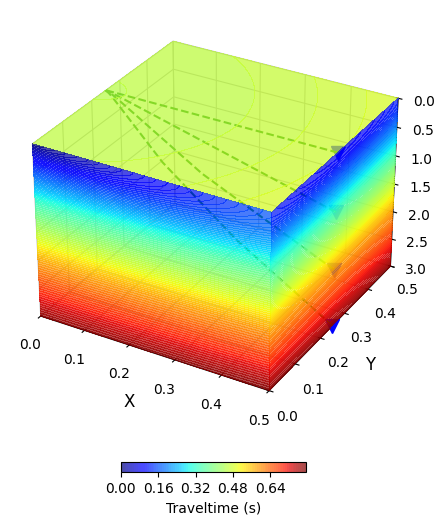

In [9]:

# Ray tracing and plotting
from pyekfmm import ray3d
plot3d(tzxy,x=x,y=y,z=z,cmap=plt.cm.jet,barlabel='Traveltime (s)',showf=False,close=False,alpha=0.7);
rz=np.linspace(0,3,4);
rx=0.5*dx/0.01;ry=0.25*dy/0.01;
for z in rz:
	paths=ray3d(time,source=[sx,sy,sz],receiver=[rx,ry,z],trim=0.1,ax=[0,dx,nx],ay=[0,dy,ny],az=[0,dz,nz])
	plt.plot(rx,ry,z,'vb',markersize=10);
	## plot rays
	plt.plot(paths[0,:],paths[1,:],paths[2,:],'g--',markersize=20);

plt.savefig('test_pyekfmm_raytracing3d-0.png',format='png',dpi=300)
# Show Figure
plt.show()